In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
import numpy as np
from IPython.display import display

df1 = pd.read_csv('trimerge19_21sep26.csv')
realTs = df1[df1['spectral_temperature'] > 0].copy()
master = df1[(df1['fit_points'] > 20) & (df1['spectral_temperature'] > 0) & (df1['gain'] > 9.9)& (df1['gain'] < 10.1)].copy()
#display(df1)
#display(realTs)
#display(master)

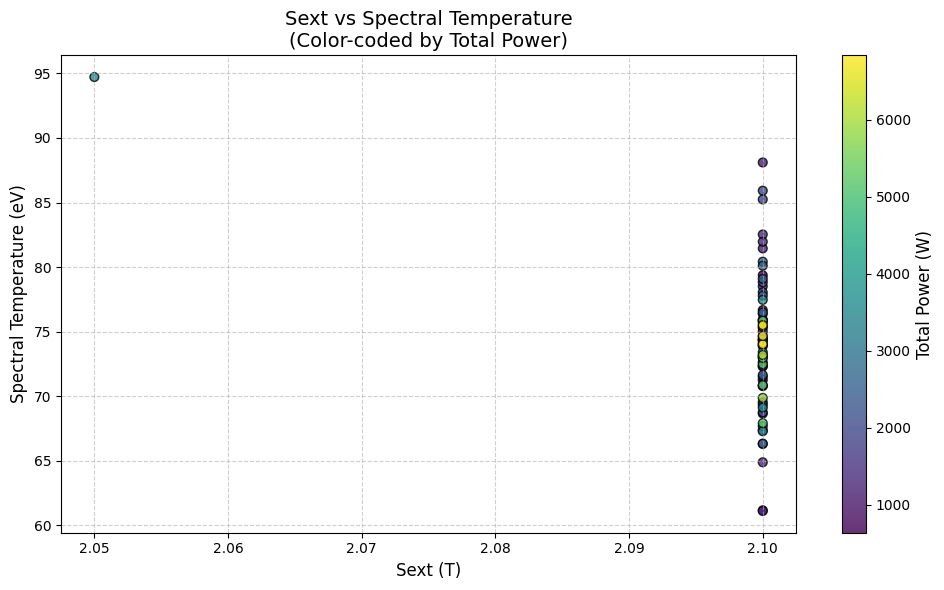

In [71]:
# 1. Ensure Total Power is calculated (if not already done)
if 'Total Power' not in master.columns:
    master['Total Power'] = master['18 GHz'] + master['28 GHz']

# 2. Drop rows with missing data in these specific columns for a clean plot
plot_df = master.dropna(subset=['Sext (T)', 'spectral_temperature', 'Total Power']).copy()

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot Sext vs Ts, colored by Total Power
scatter = plt.scatter(
    plot_df['Sext (T)'], 
    plot_df['spectral_temperature'], 
    c=plot_df['Total Power'],  # Maps the color to Total Power
    cmap='viridis',            # The color palette
    alpha=0.8,                 # Slight transparency to see overlapping points
    edgecolors='k',            # Black borders around points for clarity
    s=40                       # Marker size
)

# 4. Add the colorbar to the side
cbar = plt.colorbar(scatter)
cbar.set_label('Total Power (W)', fontsize=12)

# 5. Format the plot
plt.xlabel('Sext (T)', fontsize=12) 
plt.ylabel('Spectral Temperature (eV)', fontsize=12)
plt.title('Sext vs Spectral Temperature\n(Color-coded by Total Power)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

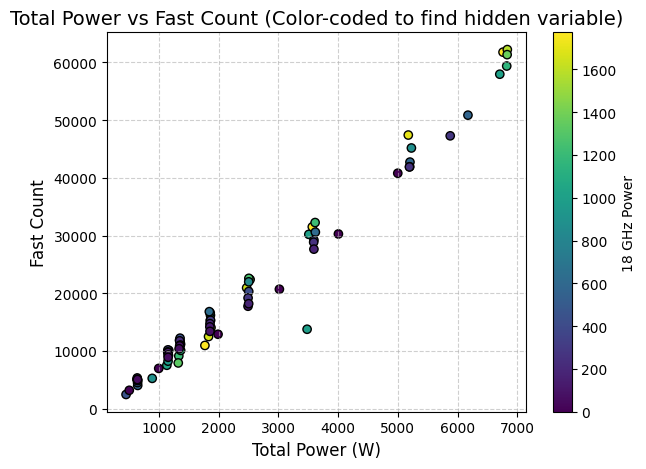

In [2]:
realTs['Total Power'] = realTs['18 GHz'] + realTs['28 GHz']
realTs['Ratio 28/18'] = realTs['28 GHz'] / realTs['18 GHz']

scatter = plt.scatter(
    realTs['Total Power'], 
    realTs['fast_count'], 
    c=realTs['18 GHz'],  # Change this to 'Ratio 28/18' or another variable to test other theories
    cmap='viridis',
    edgecolors='k'
)

plt.colorbar(scatter, label='18 GHz Power')

plt.xlabel('Total Power (W)', fontsize=12)
plt.ylabel('Fast Count', fontsize=12)
plt.title('Total Power vs Fast Count (Color-coded to find hidden variable)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

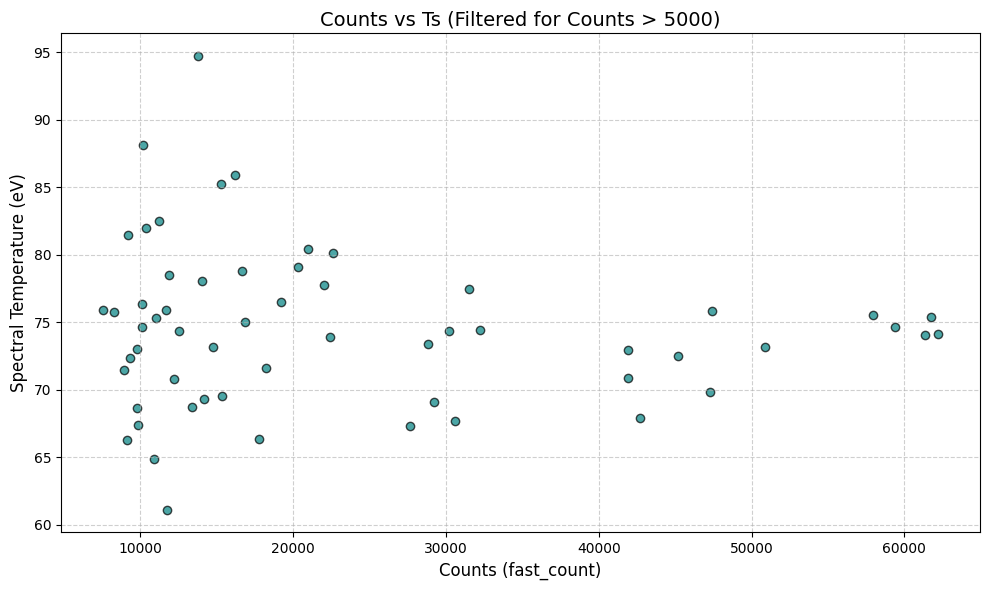

In [73]:
df_filtered = realTs[realTs['fast_count'] > 6000].copy()

# Optional but recommended: Drop rows with missing data in these columns
df_filtered.dropna(subset=['fast_count', 'spectral_temperature'], inplace=True)

# 2. Plot the filtered data
plt.figure(figsize=(10, 6))

plt.scatter(
    df_filtered['fast_count'], 
    df_filtered['spectral_temperature'], 
    alpha=0.7, 
    c='teal',         # Picked a distinct color
    edgecolors='k'    # Adds a black border to the markers for clarity
)

# Formatting the plot
plt.title('Counts vs Ts (Filtered for Counts > 5000)', fontsize=14)
plt.xlabel('Counts (fast_count)', fontsize=12)
plt.ylabel('Spectral Temperature (eV)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

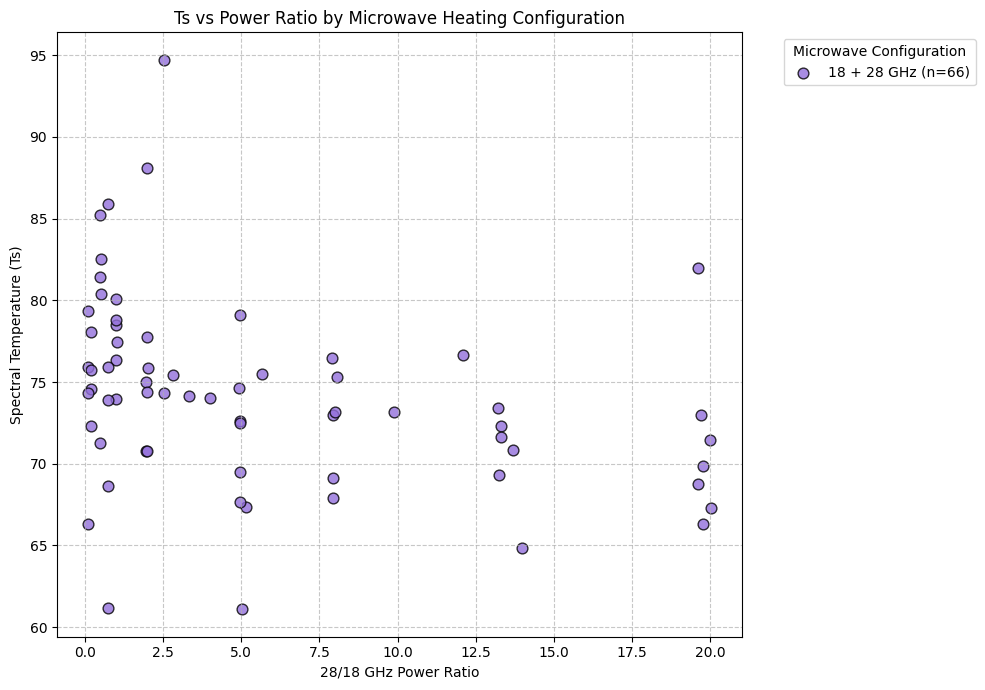

In [82]:
#Ts vs Power Ratio (28/18 GHz) for ONLY 18 and 28 GHz active

# 1. Drop rows missing the primary plotting variables
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)']).copy()

# 3. Create base conditions: "Active" (>= 50W) and "Inactive" (< 50W)
act_18 = df_plot['18 GHz'] >= 30
act_28 = df_plot['28 GHz'] >= 30

inact_18 = df_plot['18 GHz'] < 30
inact_28 = df_plot['28 GHz'] < 30

# 4. Define the 3 specific heating combinations
cond_18_only = act_18 & inact_28
cond_28_only = inact_18 & act_28
cond_18_28   = act_18 & act_28

# 5. Extract the subsets based on those conditions
df_18_only = df_plot[cond_18_only]
df_28_only = df_plot[cond_28_only]
df_18_28   = df_plot[cond_18_28]

# 6. Generate the Multi-Layer Plot
plt.figure(figsize=(10, 7))

# Plot each subset with a distinct color, black edge, and standard sizing
#plt.scatter(df_18_only['28/18 Ratio'], df_18_only['spectral_temperature'], 
            #color='dodgerblue', s=60, edgecolor='k', alpha=0.8, label=f'Only 18 GHz (n={len(df_18_only)})')

#plt.scatter(df_28_only['28/18 Ratio'], df_28_only['spectral_temperature'], 
            #color='crimson', s=60, edgecolor='k', alpha=0.8, label=f'Only 28 GHz (n={len(df_28_only)})')

plt.scatter(df_18_28['28/18 Ratio'], df_18_28['spectral_temperature'], 
            color='mediumpurple', s=60, edgecolor='k', alpha=0.8, label=f'18 + 28 GHz (n={len(df_18_28)})')

#plt.scatter(df_14_18['28/18 Ratio'], df_14_18['spectral_temperature'], 
            #color='darkorange', s=60, edgecolor='k', alpha=0.8, label=f'14 + 18 GHz (n={len(df_14_18)})')

#plt.scatter(df_all_3['28/18 Ratio'], df_all_3['spectral_temperature'], 
            #color='forestgreen', s=60, edgecolor='k', alpha=0.8, label=f'14 + 18 + 28 GHz (n={len(df_all_3)})')

# Formatting
plt.xlabel('28/18 GHz Power Ratio')
plt.ylabel('Spectral Temperature (Ts)')
plt.title('Ts vs Power Ratio by Microwave Heating Configuration')
plt.grid(True, linestyle='--', alpha=0.7)

# Move the legend outside the plot area so it doesn't cover your data
plt.legend(title='Microwave Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

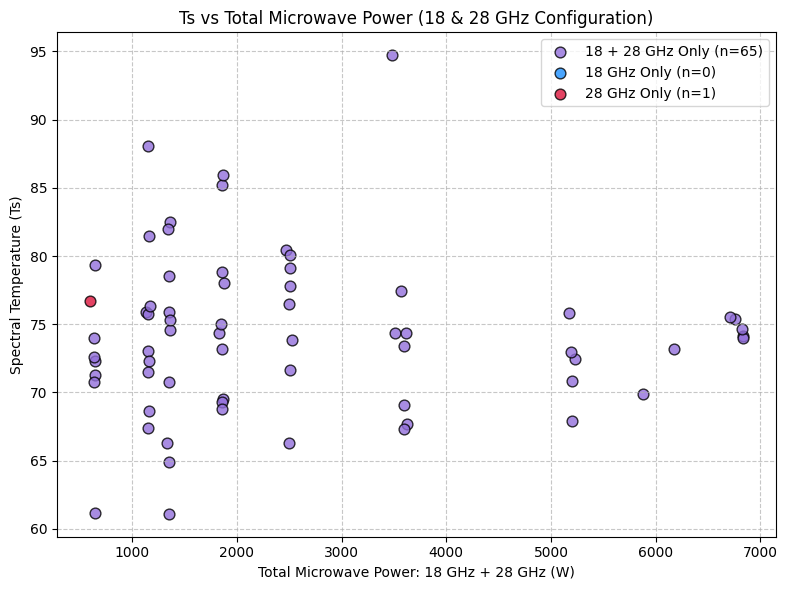

Plot successfully generated with 66 points.


In [83]:
#Ts vs Total Microwave Power (18 & 28 GHz Configuration)

# Adjust column names if they differ slightly in your active dataset
df_plot = realTs.dropna(subset=['spectral_temperature', '18 GHz', '28 GHz'], how='all').copy()

# 3. Filter for ONLY 18 GHz and 28 GHz active
# 18 and 28 must be >= 55 W, while 14 must be < 55 W
cond_18_on  = df_plot['18 GHz'] >= 55
cond_28_on  = df_plot['28 GHz'] >= 55

df_18_28_only = df_plot[cond_18_on & cond_28_on].copy()
df_18_only = df_plot[cond_18_on & (df_plot['28 GHz'] < 55)].copy()
df_28_only = df_plot[cond_28_on & (df_plot['18 GHz'] < 55)].copy()

# 4. Calculate Total Power for the x-axis
df_18_28_only['Total_Power (W)'] = df_18_28_only['18 GHz'] + df_18_28_only['28 GHz']

# 5. Generate the Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_18_28_only['Total_Power (W)'], df_18_28_only['spectral_temperature'], color='mediumpurple', s=60, edgecolor='k', alpha=0.8, label=f'18 + 28 GHz Only (n={len(df_18_28_only)})')
plt.scatter(df_18_only['18 GHz'], df_18_only['spectral_temperature'], color='dodgerblue', s=60, edgecolor='k', alpha=0.8, label=f'18 GHz Only (n={len(df_18_only)})')
plt.scatter(df_28_only['28 GHz'], df_28_only['spectral_temperature'], color='crimson', s=60, edgecolor='k', alpha=0.8, label=f'28 GHz Only (n={len(df_28_only)})')
    
    # Formatting
plt.xlabel('Total Microwave Power: 18 GHz + 28 GHz (W)')
plt.ylabel('Spectral Temperature (Ts)')
plt.title('Ts vs Total Microwave Power (18 & 28 GHz Configuration)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
    
plt.tight_layout()
plt.show()
print(f"Plot successfully generated with {len(df_18_28_only) + len(df_18_only) + len(df_28_only)} points.")

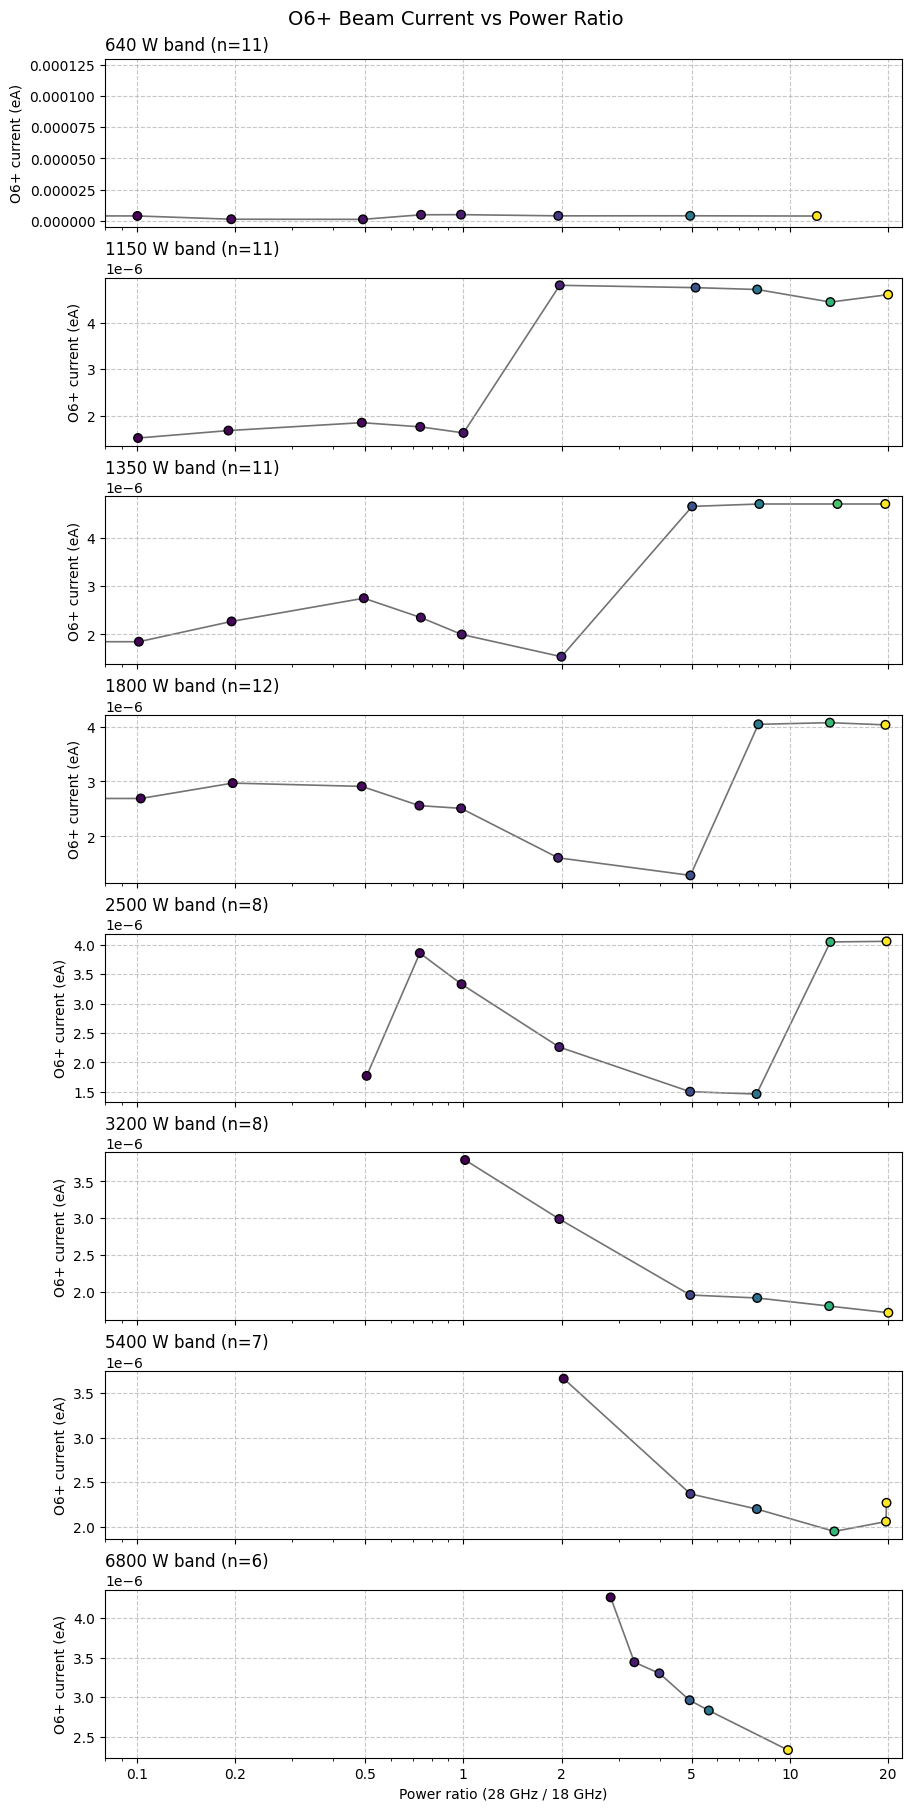

Plotted 74 points from runs greater than 2.


In [7]:
# O6+ beam current versus 28/18 GHz power ratio, one subplot per power band

power_bands = np.array([640, 1150, 1350, 1800, 2500, 3200, 5400, 6800])
ratio_ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20]

# Exclude setup runs 1 and 2 and keep only complete two-frequency O6+ measurements.
df_power = realTs[
    (realTs['Run'] > 2) &
    realTs['18 GHz'].notna() &
    realTs['28 GHz'].notna()
].dropna(subset=['O6+_beam_current']).copy()

df_power['Total Power'] = df_power['18 GHz'] + df_power['28 GHz']
df_power['28/18 Ratio'] = df_power['28 GHz'] / df_power['18 GHz']
df_power['Power Band'] = df_power['Total Power'].apply(
    lambda power: power_bands[np.argmin(np.abs(power_bands - power))]
)

fig, axes = plt.subplots(
    len(power_bands),
    1,
    figsize=(9, 18),
    sharex=True,
    constrained_layout=True
)

for axis, band in zip(axes, power_bands):
    subset = df_power[df_power['Power Band'] == band].sort_values('28/18 Ratio')

    axis.plot(
        subset['28/18 Ratio'],
        subset['O6+_beam_current'],
        color='0.45',
        linewidth=1.2,
        zorder=1
    )
    axis.scatter(
        subset['28/18 Ratio'],
        subset['O6+_beam_current'],
        c=subset['28/18 Ratio'],
        cmap='viridis',
        marker='o',
        s=38,
        edgecolors='k',
        zorder=2
    )
    axis.set_title(f'{band} W band (n={len(subset)})', loc='left')
    axis.set_ylabel('O6+ current (eA)')
    axis.grid(True, linestyle='--', alpha=0.7)

axes[-1].set_xscale('log')
axes[-1].set_xticks(ratio_ticks)
axes[-1].set_xticklabels(['0.1', '0.2', '0.5', '1', '2', '5', '10', '20'])
axes[-1].set_xlim(0.08, 22)
axes[-1].set_xlabel('Power ratio (28 GHz / 18 GHz)')
fig.suptitle('O6+ Beam Current vs Power Ratio', fontsize=14)
plt.show()

print(f'Plotted {len(df_power)} points from runs greater than 2.')

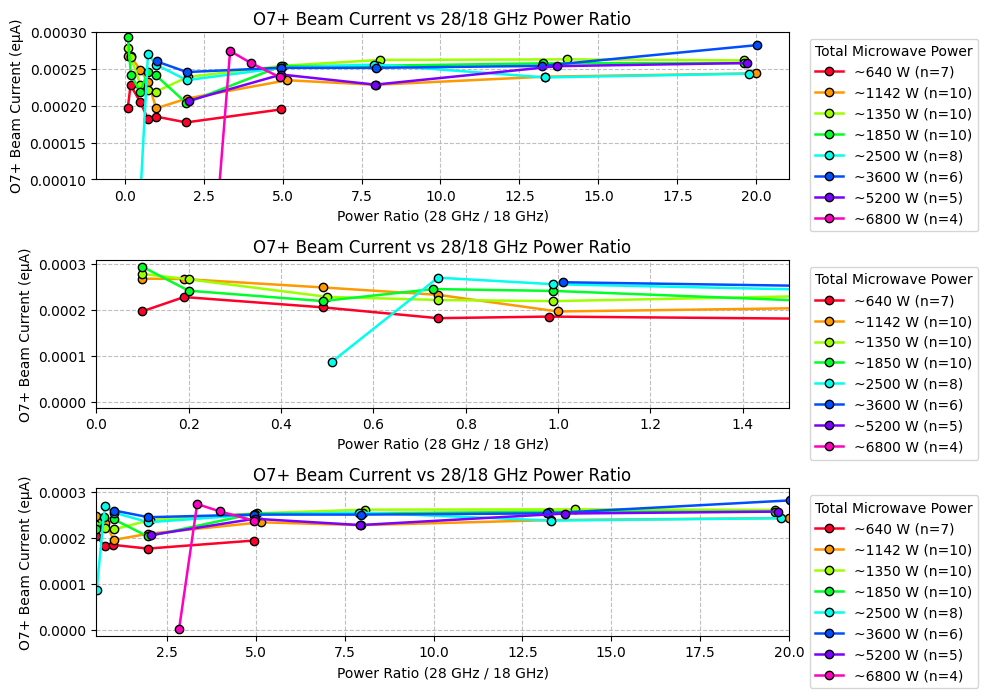

Plotted 60 points.


In [104]:
# O7+ current versus 28/18 GHz power ratio, shown as lines

targets = np.array([640, 1142, 1350, 1850, 2500, 3600, 5200, 6800])
tolerance = 40

df_power = realTs.dropna(
    subset=['O7+_beam_current', '18 GHz', '28 GHz']
).copy()

df_power = df_power[
    (df_power['18 GHz'] >= 55) &
    (df_power['28 GHz'] >= 55)
].copy()

df_power['Power_Group'] = df_power['Total Power'].apply(
    lambda power: targets[np.argmin(np.abs(targets - power))]
)

df_power = df_power[
    abs(df_power['Total Power'] - df_power['Power_Group']) <= tolerance
].copy()

fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(10, 7))
colors = plt.cm.gist_rainbow(np.linspace(0, 1, len(targets)))

for target, color in zip(targets, colors):
    subset = df_power[df_power['Power_Group'] == target].copy()

    if not subset.empty:
        subset = subset.sort_values('28/18 Ratio')

        ax1.plot(
            subset['28/18 Ratio'],
            subset['O7+_beam_current'],
            color=color,
            marker='o',
            markersize=6,
            linewidth=1.8,
            markeredgecolor='k',
            label=f'~{target} W (n={len(subset)})'
        )

for target, color in zip(targets, colors):
    subset = df_power[df_power['Power_Group'] == target].copy()

    if not subset.empty:
        subset = subset.sort_values('28/18 Ratio')

        ax2.plot(
            subset['28/18 Ratio'],
            subset['O7+_beam_current'],
            color=color,
            marker='o',
            markersize=6,
            linewidth=1.8,
            markeredgecolor='k',
            label=f'~{target} W (n={len(subset)})'
        ) 

for target, color in zip(targets, colors):
    subset = df_power[df_power['Power_Group'] == target].copy()

    if not subset.empty:
        subset = subset.sort_values('28/18 Ratio')

        ax3.plot(
            subset['28/18 Ratio'],
            subset['O7+_beam_current'],
            color=color,
            marker='o',
            markersize=6,
            linewidth=1.8,
            markeredgecolor='k',
            label=f'~{target} W (n={len(subset)})'
        )       

ax1.set_xlabel('Power Ratio (28 GHz / 18 GHz)')
ax1.set_ylim(0.0001,0.0003)
ax1.set_ylabel('O7+ Beam Current (eμA)')
ax1.set_title('O7+ Beam Current vs 28/18 GHz Power Ratio')
ax1.grid(True, linestyle='--', alpha=0.8)
ax1.legend(
    title='Total Microwave Power',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax2.set_xlabel('Power Ratio (28 GHz / 18 GHz)')
ax2.set_xlim(0,1.5)
ax2.set_ylabel('O7+ Beam Current (eμA)')
ax2.set_title('O7+ Beam Current vs 28/18 GHz Power Ratio')
ax2.grid(True, linestyle='--', alpha=0.8)
ax2.legend(
    title='Total Microwave Power',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax3.set_xlabel('Power Ratio (28 GHz / 18 GHz)')
ax3.set_xlim(0.5,20)
ax3.set_ylabel('O7+ Beam Current (eμA)')
ax3.set_title('O7+ Beam Current vs 28/18 GHz Power Ratio')
ax3.grid(True, linestyle='--', alpha=0.8)
ax3.legend(
    title='Total Microwave Power',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

print(f'Plotted {len(df_power)} points.')

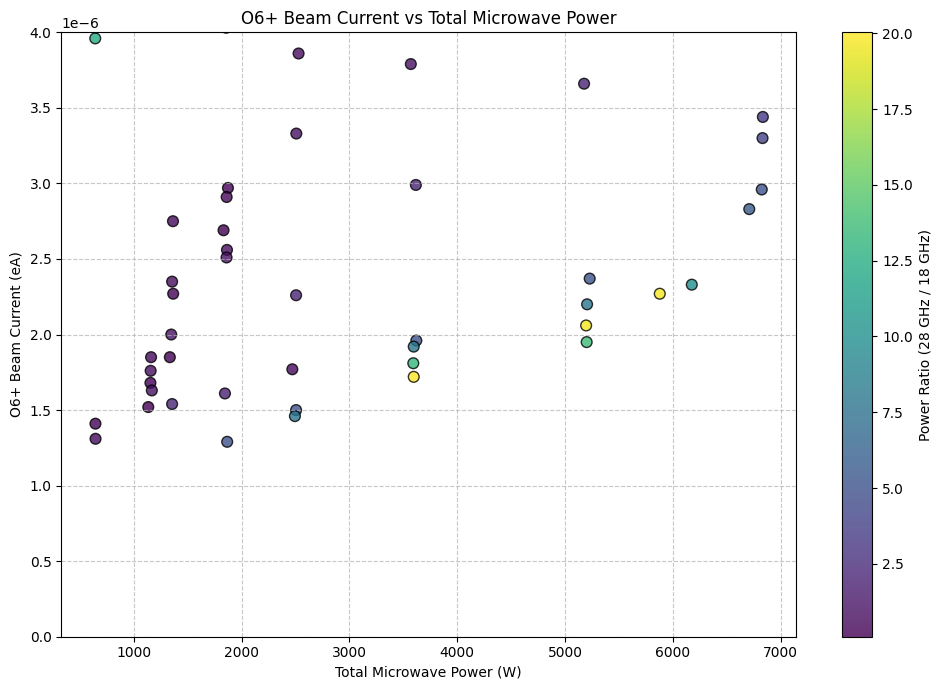

Plotted 64 points.


In [95]:
# O6+ beam current versus total microwave power

df_power = realTs.dropna(
    subset=["O6+_beam_current", "18 GHz", "28 GHz"]
).copy()

df_power["Total Power"] = (
    df_power["18 GHz"] + df_power["28 GHz"]
)

df_power = df_power.dropna(
    subset=["Total Power", "O6+_beam_current"]
)

plt.figure(figsize=(10, 7))

plt.scatter(
    df_power["Total Power"],
    df_power["O6+_beam_current"],
    c=df_power["28/18 Ratio"]
    if "28/18 Ratio" in df_power.columns
    else "steelblue",
    cmap="viridis" if "28/18 Ratio" in df_power.columns else None,
    marker="o",
    s=60,
    alpha=0.8,
    edgecolors="k",
)

if "28/18 Ratio" in df_power.columns:
    plt.colorbar(
        label="Power Ratio (28 GHz / 18 GHz)"
    )

plt.xlabel("Total Microwave Power (W)")
plt.ylabel("O6+ Beam Current (eA)")
plt.title("O6+ Beam Current vs Total Microwave Power")
plt.ylim(0, 0.000004)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Plotted {len(df_power)} points.")

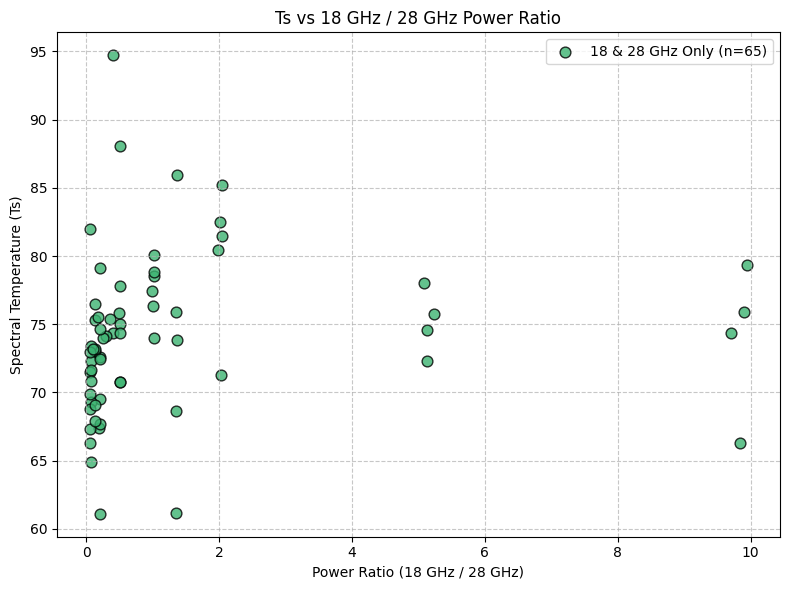

Plot successfully generated with 65 points.


In [96]:
#Ts vs Power Ratio (18 GHz / 28 GHz)

# 3. Filter for ONLY 18 GHz and 28 GHz active
# 18 and 28 must be >= 50 W, while 14 must be < 50 W
cond_18_on  = df_plot['18 GHz'] >= 50
cond_28_on  = df_plot['28 GHz'] >= 50

df_18_28_only = df_plot[cond_18_on & cond_28_on].copy()

# 4. Calculate the Power Ratio for the x-axis (18 GHz / 28 GHz)
df_18_28_only['Power_Ratio_18_28'] = df_18_28_only['18 GHz'] / df_18_28_only['28 GHz']

# 5. Generate the Plot
if len(df_18_28_only) > 0:
    plt.figure(figsize=(8, 6))
    
    plt.scatter(df_18_28_only['Power_Ratio_18_28'], df_18_28_only['spectral_temperature'], 
                color='mediumseagreen', s=60, edgecolor='k', alpha=0.8, 
                label=f'18 & 28 GHz Only (n={len(df_18_28_only)})')
    
    # Formatting
    plt.xlabel('Power Ratio (18 GHz / 28 GHz)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs 18 GHz / 28 GHz Power Ratio')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_18_28_only)} points.")
else:
    print("No valid data points found where exactly 18 GHz and 28 GHz were active.")